In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import scrublet as scr
import scipy.io
import matplotlib.pyplot as plt
import os
import bbknn as bk
import scvelo as scv
import anndata
sc.settings.set_figure_params(dpi=300,fontsize=10)

In [ ]:
macrolognorm = sc.read_h5ad('data/macrolognorm.h5ad')

In [ ]:
sc.tl.pca(macrolognorm, svd_solver='arpack',random_state=2)
bk.bbknn(macrolognorm)
sc.tl.umap(macrolognorm,random_state=2)

In [ ]:
macrolognorm.obs

In [ ]:
sc.settings.set_figure_params(dpi=300,fontsize=14)

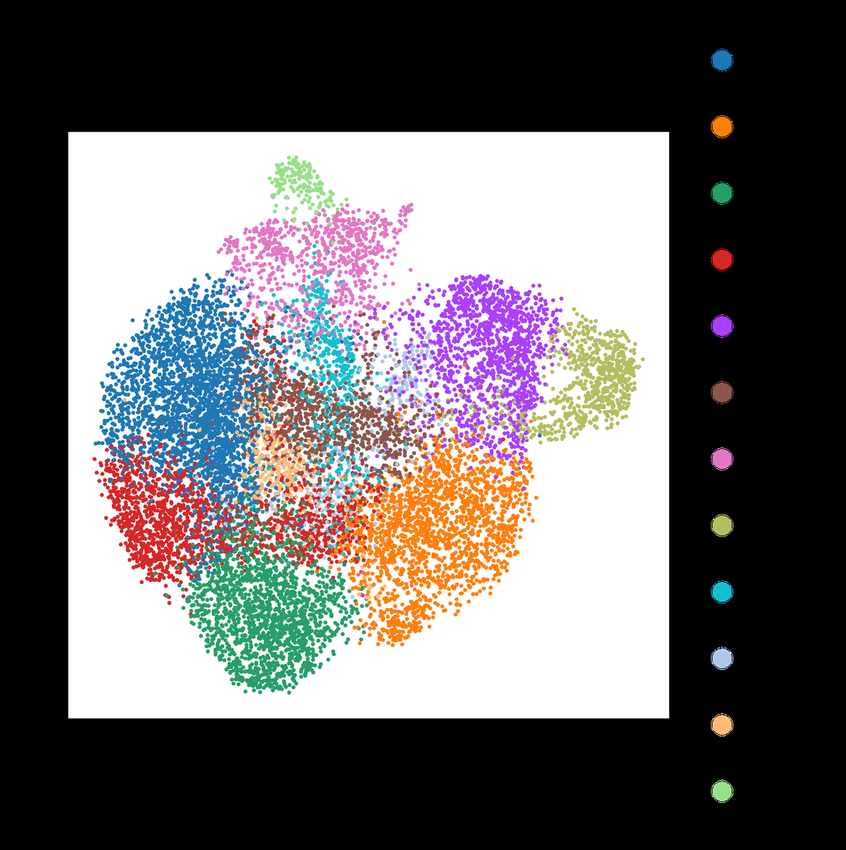

In [ ]:
sc.tl.leiden(macrolognorm,resolution=0.6,n_iterations=-1,random_state=2)
sc.pl.umap(macrolognorm,color='leiden',legend_fontsize='large',use_raw=True)

In [ ]:
sc.tl.rank_genes_groups(macrolognorm,groupby='leiden',n_genes=10,method='logreg',corr_method='bonferroni', use_raw = True)

In [ ]:
sc.tl.dendrogram(macrolognorm,groupby='Subclusters')

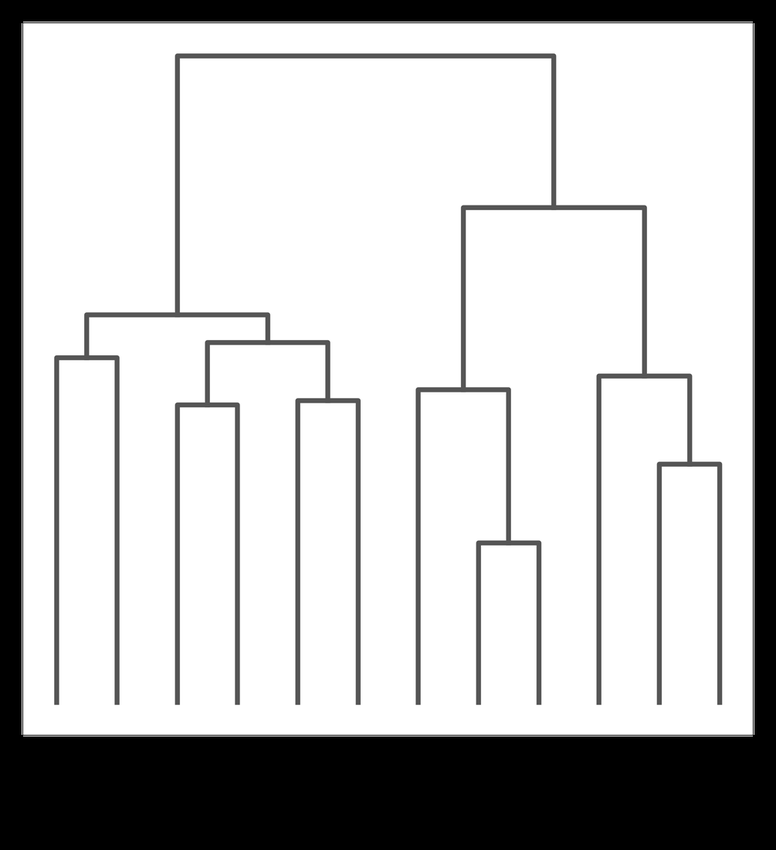

In [ ]:
sc.pl.dendrogram(macrolognorm,groupby='Subclusters')

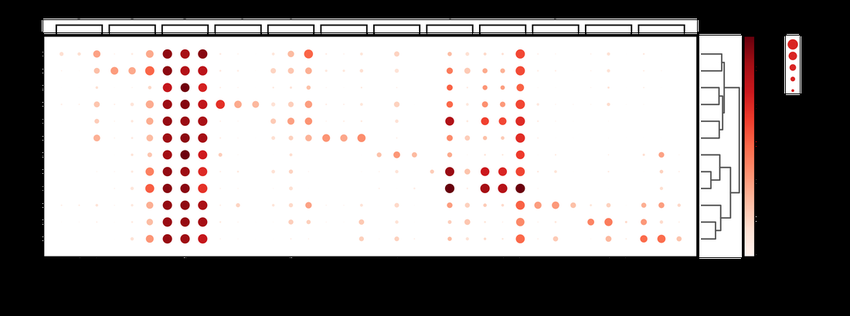

In [ ]:
sc.pl.rank_genes_groups_dotplot(macrolognorm, n_genes=3,use_raw = True)

In [ ]:
sc.tl.filter_rank_genes_groups(macrolognorm, min_fold_change=2)

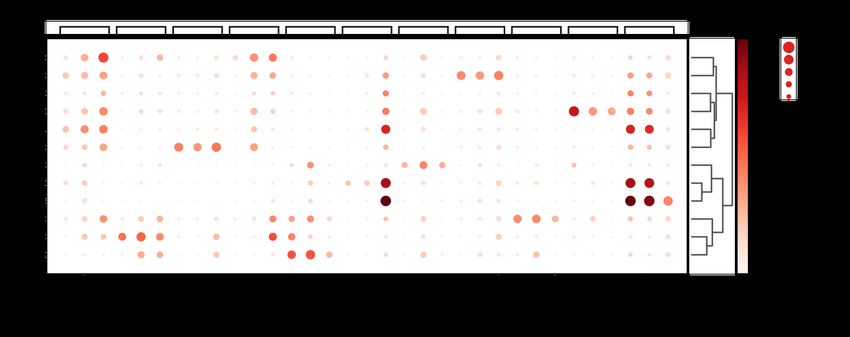

In [ ]:
sc.pl.rank_genes_groups_dotplot(macrolognorm,n_genes=3,key='rank_genes_groups_filtered',smallest_dot=10,use_raw = True)

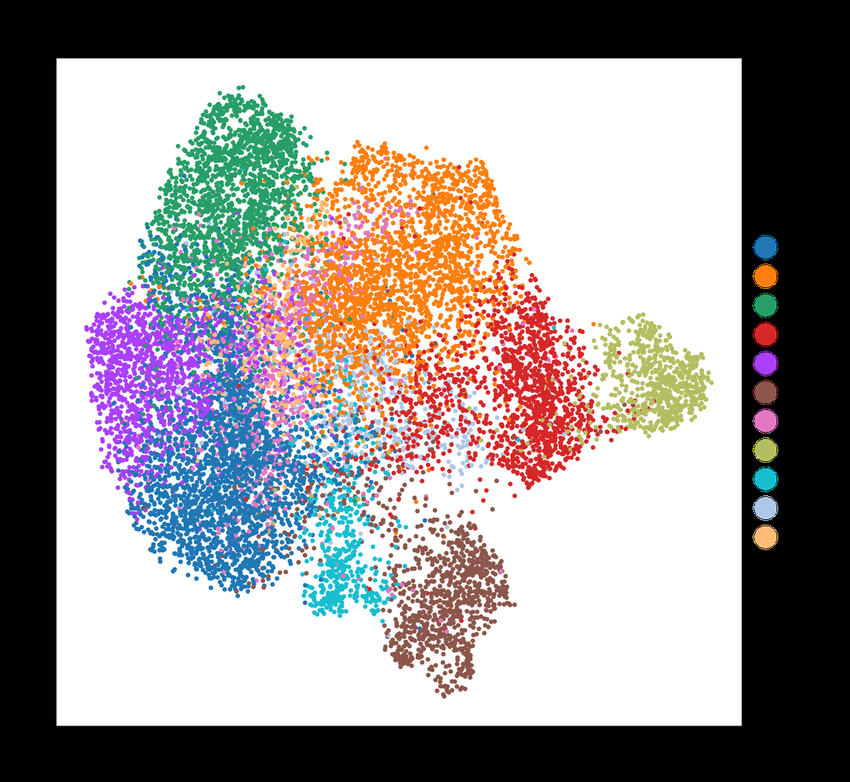

In [ ]:
sc.settings.set_figure_params(dpi=300,fontsize=7)
sc.pl.umap(macrolognorm,color='cluster',use_raw=True)

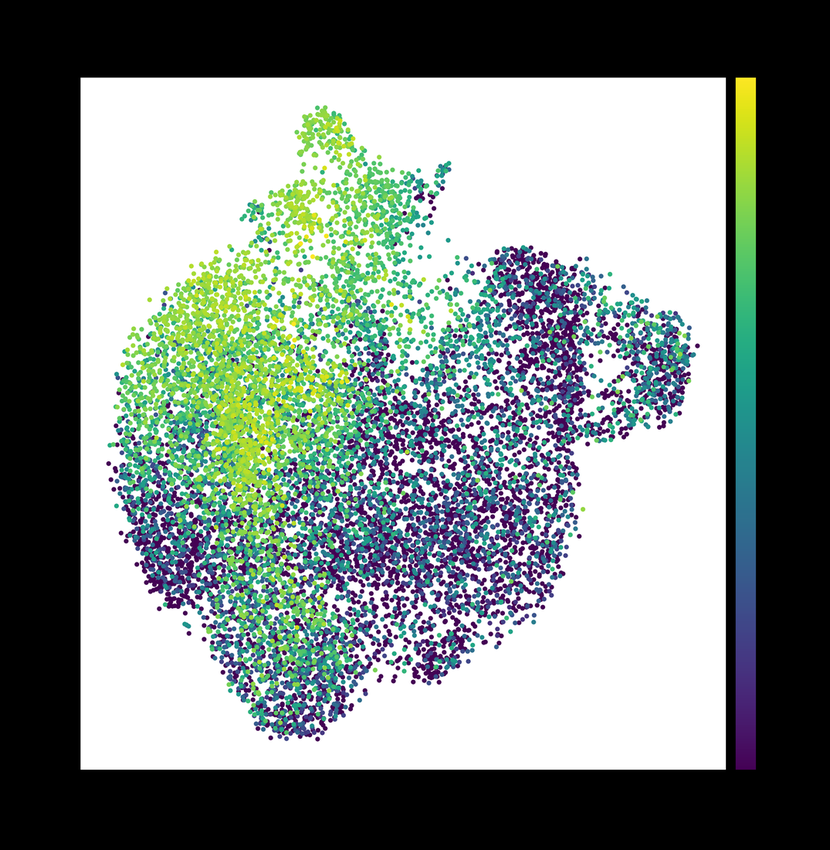

In [ ]:
sc.pl.umap(macrolognorm,color='Cd74',use_raw=True)

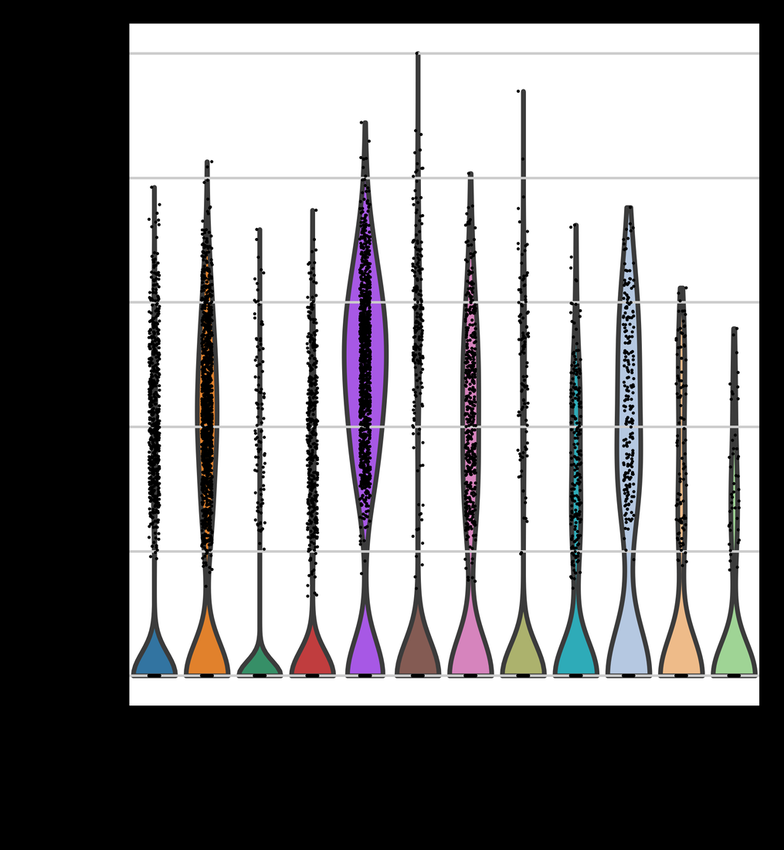

In [ ]:
sc.pl.violin(macrolognorm,['Ccr2'],groupby='leiden',use_raw=True)

In [ ]:
sc.tl.rank_genes_groups(macrolognorm, 'MI', method = 't-test', n_genes = 500, use_raw = True)
result = macrolognorm.uns['rank_genes_groups']
groups = result['names'].dtype.names
markers = pd.DataFrame(
{group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges','scores']})
markers.head(10)

In [ ]:
markers.to_csv('data/macro_dge.csv')

In [ ]:
	def filtered_DEG_names(macrolognorm, q_value = 1E-5, fold_change = 1, save = False):
		result = macrolognorm.uns['rank_genes_groups']
		groups = result['names'].dtype.names
		markers = pd.DataFrame(
		{group + '_' + key[:1]: result[key][group]
			for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges']})
		output = pd.DataFrame()
		for i in groups:
			temp = markers[(markers.loc[:,i+'_p'] <= q_value) & (markers.loc[:,i+'_l'] >= fold_change)].loc[:,(i+'_n')]
			temp.reset_index(inplace=True, drop=True)
			output = output.join(temp, how='outer')
		if(save != False):
			if(save == True):
				output.transpose().to_csv('./filtered_DEG_names.csv', sep = ',', index = True, header=False)
			else:
				output.transpose().to_csv(save, sep = ',', index = True, header=False)
		return output

	filtered_DEG_names(macrolognorm, save="./filtered_MI_DEG_names.csv")

In [ ]:
macro_genes = pd.DataFrame(macrolognorm.uns['rank_genes_groups']['names']).head(5)

In [ ]:
macro_genes.to_csv('data/macro_genes.csv')

In [ ]:
macro_genes.to_pdf('data/macro_genes.pdf')

In [ ]:
#cluster 2 = 5 and 3
#cluster 5 = 8
#cluster 6 = 8 and 11

In [ ]:
macrolognorm.var_names

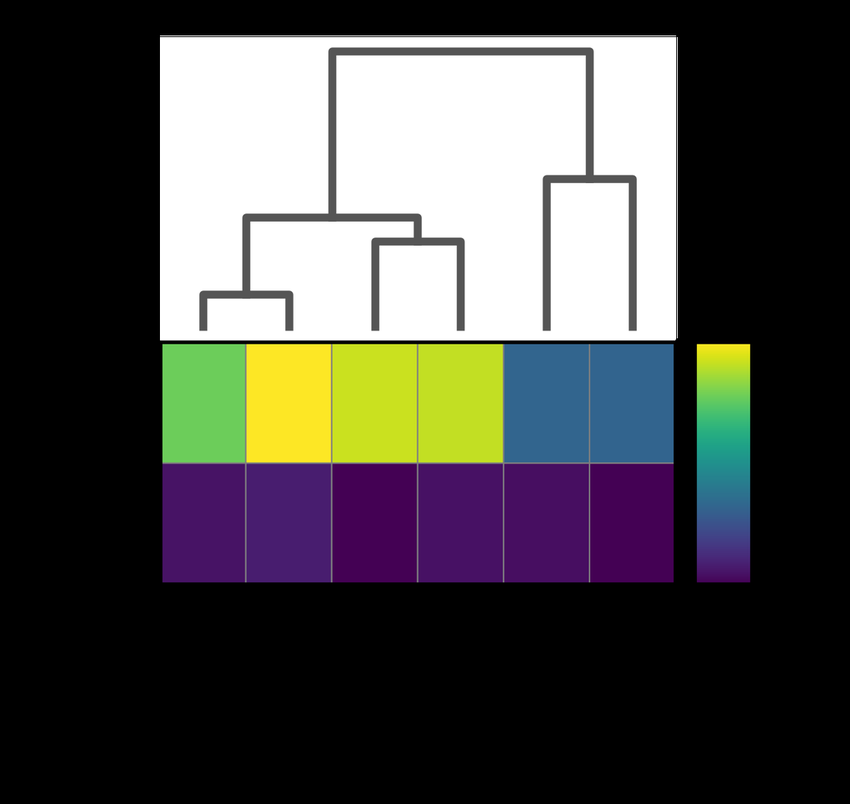

In [ ]:
sc.pl.matrixplot(macrolognorm,var_names=['C1qa','Alox5'],groupby='MI',dendrogram=True,swap_axes=True)

In [ ]:
macro_cell_counts = pd.crosstab(macrolognorm.obs.cluster, macrolognorm.obs.MI)

In [ ]:
macro_cell_counts.to_csv('data/macro_cc.csv')

In [ ]:
from SCCAF import SCCAF_assessment, plot_roc
import scanpy as sc

y_prob, y_pred, y_test, clf, cvsm, acc = SCCAF_assessment(macrolognorm.X, macrolognorm.obs['cluster'], n=100)

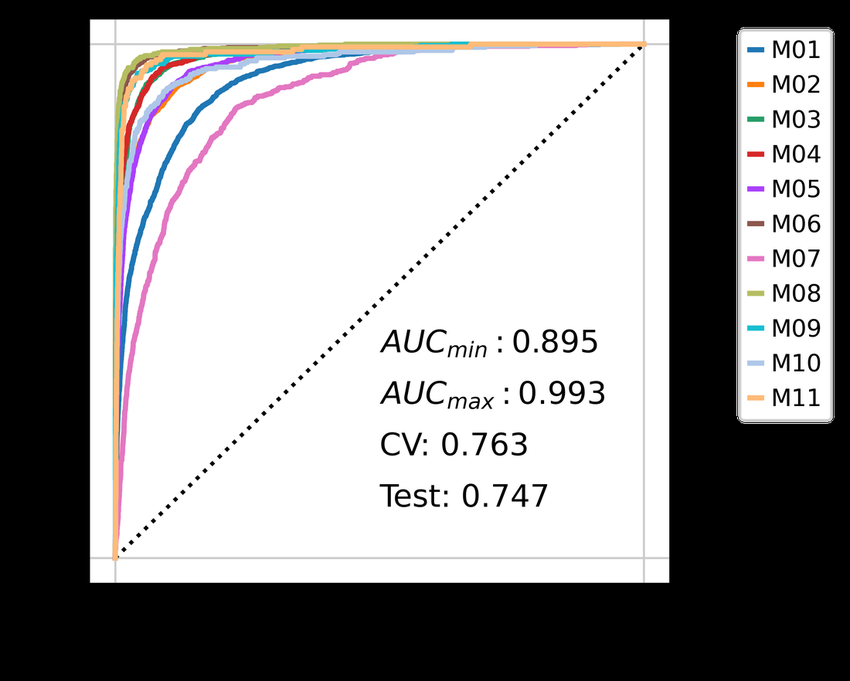

In [ ]:
import matplotlib.pyplot as plt

sc.settings.set_figure_params(dpi=300,fontsize=10)
plot_roc(y_prob, y_test, clf, cvsm=cvsm, acc=acc,plot='roc',fontsize=12)
plt.legend(bbox_to_anchor=(1.1, 1.0))
plt.show()

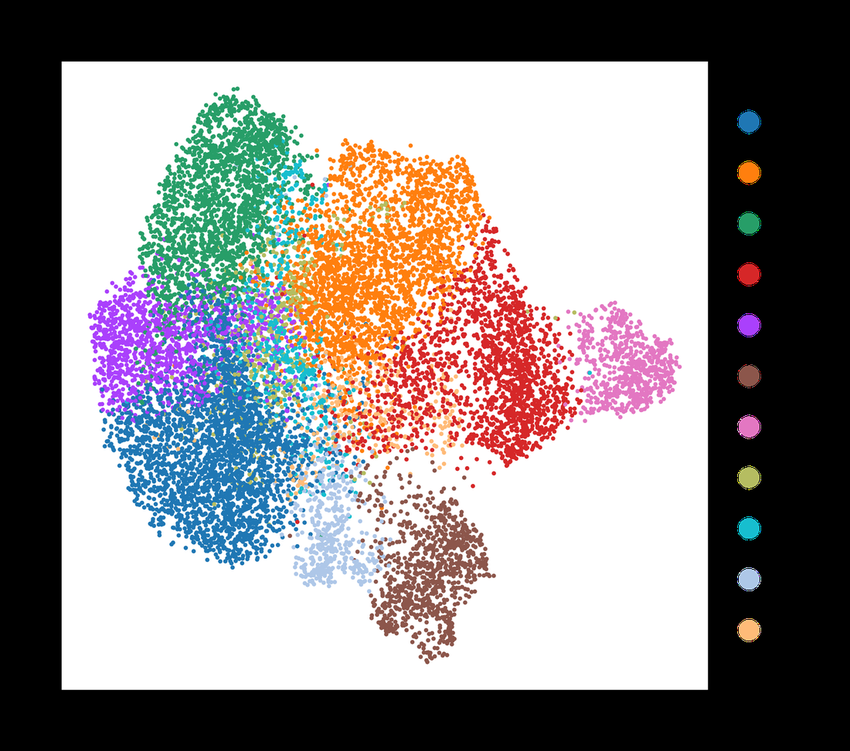

In [ ]:
sc.tl.leiden(macrolognorm,resolution=0.60,n_iterations=-1, random_state = 2)
sc.pl.umap(macrolognorm,color='leiden',legend_fontsize='large')

In [ ]:
y_prob, y_pred, y_test, clf, cvsm, acc = SCCAF_assessment(macrolognorm.X, macrolognorm.obs['leiden'], n=100)

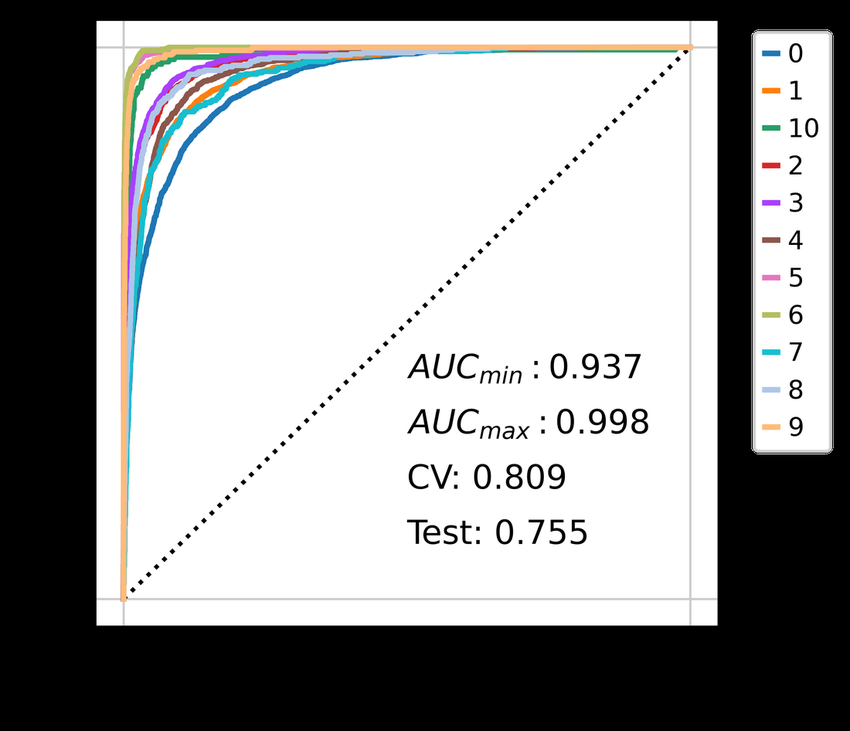

In [ ]:
import matplotlib.pyplot as plt

plot_roc(y_prob, y_test, clf, cvsm=cvsm, acc=acc,plot='roc',fontsize=12)
plt.legend(bbox_to_anchor=(1.2, 1.0))
plt.show()

In [ ]:
macrolognorm.obs['Subclusters'] = macrolognorm.obs['leiden']
macrolognorm.obs['Subclusters'].cat.categories = ['M1','M2','M3','M4','M5','M6','M7','M8','M9','M10','M11','M12']

In [ ]:
sc.tl.rank_genes_groups(macrolognorm, 'Subclusters', method = 'wilcoxon', corr_method='bonferroni', n_genes = 500, use_raw = True)
result = macrolognorm.uns['rank_genes_groups']
groups = result['names'].dtype.names
markers = pd.DataFrame(
{group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges','scores']})
markers.head(10)

In [ ]:
def DEG_table(macrolognorm):
    result = macrolognorm.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    markers = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
        for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges']})
    return markers

In [ ]:
def filtered_DEG_names(macrolognorm, q_value = 1E-5, fold_change = 1):
    markers = DEG_table(macrolognorm)
    groups = macrolognorm.uns['rank_genes_groups']['names'].dtype.names
    output = pd.DataFrame()
    for i in groups:
        temp = markers[(markers.loc[:,i+'_p'] <= q_value) & (markers.loc[:,i+'_l'] >= 
fold_change)].loc[:,(i+'_n')]
        temp.reset_index(inplace=True, drop=True)
        output = output.join(temp, how='outer')
    return output

In [ ]:
filtered_deg = filtered_DEG_names(macrolognorm)

In [ ]:
filtered_deg

In [ ]:
filtered_deg.to_csv('data/macro_filt_sub.csv')

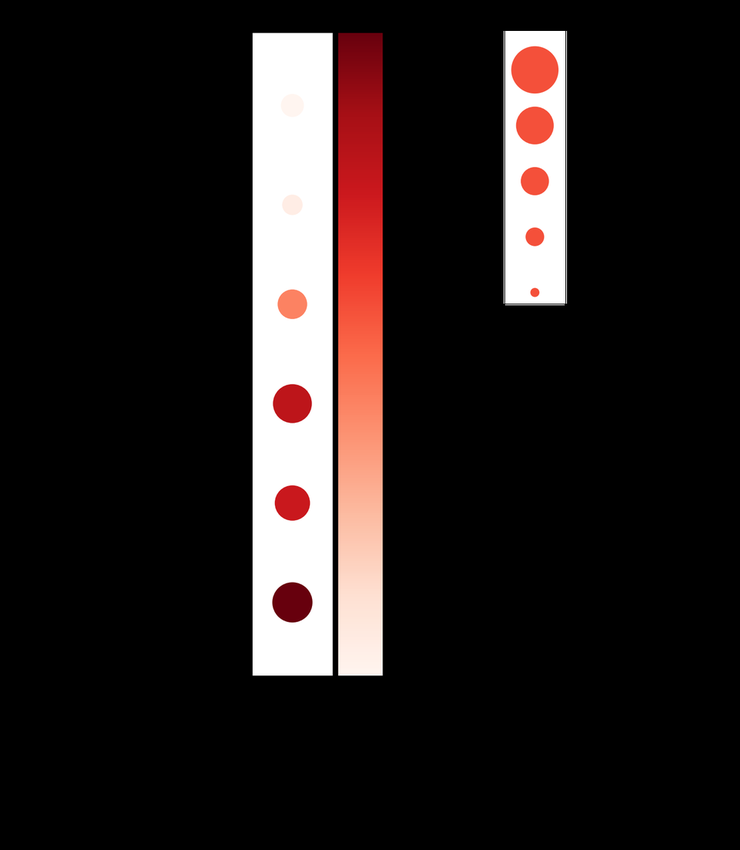

In [ ]:
marker = pd.read_csv("data/ligands.csv") 
sc.settings.set_figure_params(dpi=300,fontsize=12)

marker=marker['Name'] #'Name' is the name of the column in the csv file containing the gene names
marker_genes = np.asarray(marker)

ax = sc.pl.dotplot(macrolognorm, var_names=['Cd74'],groupby= 'MI',use_raw=True) #change groupby can be anything in adata.obs
#above is loading the directory. Basically same thing